In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [3]:
# Load dataset
df = pd.read_csv("Dataset/academic_meals_elementary_district.csv")

print("Original shape:", df.shape)

Original shape: (54, 263)


### Remove null values

In [4]:
total_nulls = df.isnull().sum().sum()

print("Total missing values in dataset:", total_nulls)

Total missing values in dataset: 1


In [5]:
null_per_column = df.isnull().sum()

print(null_per_column)

District                         0
ROE                              0
student_disabilities_percent     1
student_low_income_percent       0
days_entered.x                   0
                                ..
Science_Proficiency              0
Science_Proficiency_LowIncome    0
Science_Proficiency_CWD          0
missing_frac                     0
missing_count                    0
Length: 263, dtype: int64


In [6]:
# Check which row has missing value
df[df["student_disabilities_percent"].isnull()]

,District,ROE,student_disabilities_percent,student_low_income_percent,days_entered.x,HEI 2015 Total Score,HEI 2015 Total Fruits (0-5),HEI 2015 Whole Fruits (0-5),HEI 2015 Total Vegetables (0-5),HEI 2015 Greens and Beans (0-5),...,ELA_Proficiency_LowIncome,ELA_Proficiency_CWD,Math_Proficiency,Math_Proficiency_LowIncome,Math_Proficiency_CWD,Science_Proficiency,Science_Proficiency_LowIncome,Science_Proficiency_CWD,missing_frac,missing_count
27,LOSTANT CUSD 425,35.0,NaN,26.8,21.0,67.000048,5.0,5.0,2.93481,3.043476,...,60.558345,44.231892,30.8,27.499899,27.739182,42.316915,40.73494,51.344596,0.7,7.0


In [7]:
median_value = df["student_disabilities_percent"].median()

df["student_disabilities_percent"] = df["student_disabilities_percent"].fillna(median_value)

print("Missing after imputation:", df["student_disabilities_percent"].isnull().sum())

Missing after imputation: 0


### Step 1: Remove non analytical (unnecessary) columns

In [8]:
cols_to_drop = [
    # Identifiers
    "ROE",
    
    # Tracking / merge artifacts
    "days_entered.x",
    "days_entered.y",
    "Day of Menu",
    
    # Metadata
    "Data Collected in NCC Database Version",
    "Data Collected in Software Version",
    "Data Generated in NCC Database Version",
    "Data Generated in Software Version",
    
    # Missing diagnostics 
    "missing_frac",
    "missing_count",

    "ELA_Proficiency_LowIncome",
    "ELA_Proficiency_CWD",
    "Math_Proficiency_LowIncome",
    "Math_Proficiency_CWD",
    "Science_Proficiency_LowIncome",
    "Science_Proficiency_CWD"
]

In [9]:
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print("After removing non-analytical columns:", df_clean.shape)

After removing non-analytical columns: (54, 247)


In [10]:
removed = set(df.columns) - set(df_clean.columns)
print("Removed columns:")
print(removed)

Removed columns:
{'Science_Proficiency_CWD', 'ELA_Proficiency_CWD', 'Day of Menu', 'Data Collected in NCC Database Version', 'Data Generated in NCC Database Version', 'days_entered.y', 'Science_Proficiency_LowIncome', 'missing_count', 'ROE', 'missing_frac', 'Data Collected in Software Version', 'Data Generated in Software Version', 'days_entered.x', 'ELA_Proficiency_LowIncome', 'Math_Proficiency_LowIncome', 'Math_Proficiency_CWD'}


### Step 2: Removing duplicate columns (redundant columns)

In [11]:
# Identify columns ending with .x or .y
x_cols = [col for col in df_clean.columns if col.endswith(".x")]
y_cols = [col for col in df_clean.columns if col.endswith(".y")]

print("Columns ending with .x:", x_cols)
print("Columns ending with .y:", y_cols)

Columns ending with .x: ['% Calories from SFA.x', 'Total Saturated Fatty Acids (SFA) (g).x', 'Energy (kcal).x']
Columns ending with .y: ['Energy (kcal).y', 'Total Saturated Fatty Acids (SFA) (g).y', '% Calories from SFA.y']


In [12]:
# Remove .x / .y Duplicate Columns (Keep One)
cols_to_drop = []

for col in x_cols:
    base_name = col[:-2]  # remove ".x"
    y_version = base_name + ".y"
    
    if y_version in df_clean.columns:
        # If both exist, drop the .y version
        cols_to_drop.append(y_version)

df_clean = df_clean.drop(columns=cols_to_drop)

print("Removed duplicate .y columns")
print("New shape:", df_clean.shape)


Removed duplicate .y columns
New shape: (54, 244)


In [13]:
# Remove EXACT Duplicate Columns (Same Values)
import numpy as np

duplicate_columns = []

for i in range(len(df_clean.columns)):
    for j in range(i + 1, len(df_clean.columns)):
        col1 = df_clean.columns[i]
        col2 = df_clean.columns[j]
        
        if df_clean[col1].equals(df_clean[col2]):
            duplicate_columns.append(col2)

# Remove duplicates
df_clean = df_clean.drop(columns=list(set(duplicate_columns)))

print("Exact duplicate columns removed:", duplicate_columns)
print("Shape after removing exact duplicates:", df_clean.shape)

Exact duplicate columns removed: ['Whole Grains (ounce equivalents)', 'Refined Grains (ounce equivalents)', 'Sucrose Polyester (g)', 'User Nutrient 1 (mg)', 'User Nutrient 2 (mg)', 'User Nutrient 3 (mg)', 'User Nutrient 4 (mg)', 'User Nutrient 5 (mg)', 'User Nutrient 6 (mg)', 'User Nutrient 7 (mg)', 'User Nutrient 8 (mg)', 'User Nutrient 9 (mg)', 'User Nutrient 10 (mg)', 'User Nutrient 11 (mg)', 'User Nutrient 12 (mg)', 'User Nutrient 13 (mg)', 'User Nutrient 14 (mg)', 'User Nutrient 15 (mg)', 'User Nutrient 16 (mg)', 'User Nutrient 17 (mg)', 'User Nutrient 18 (mg)', 'User Nutrient 19 (mg)', 'User Nutrient 20 (mg)', 'Sucralose (mg)', 'Isomalt (g)', 'Lactitol (g)', 'User Nutrient 1 (mg)', 'User Nutrient 2 (mg)', 'User Nutrient 3 (mg)', 'User Nutrient 4 (mg)', 'User Nutrient 5 (mg)', 'User Nutrient 6 (mg)', 'User Nutrient 7 (mg)', 'User Nutrient 8 (mg)', 'User Nutrient 9 (mg)', 'User Nutrient 10 (mg)', 'User Nutrient 11 (mg)', 'User Nutrient 12 (mg)', 'User Nutrient 13 (mg)', 'User Nutri

In [14]:
# Remove Duplicate Energy Columns
energy_cols = [col for col in df_clean.columns if "Energy" in col]
print("Energy-related columns:", energy_cols)

Energy-related columns: ['Energy (kcal).x', 'Energy (kj)']


In [15]:
if "Energy (kj)" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Energy (kj)"])

In [16]:
print("Final shape after duplicate removal:", df_clean.shape)

Final shape after duplicate removal: (54, 217)


### Step 4: Remove Low-Variance Predictors (Variance measures how much a variable changes across districts)

In [17]:
# Keep numeric columns only
df_numeric = df_clean.select_dtypes(include=[np.number])

print("Numeric shape:", df_numeric.shape)

Numeric shape: (54, 216)


In [18]:
variances = df_numeric.var()

# Look at smallest variances
variances.sort_values().head(10)

Saccharin (mg)                                     0.000000e+00
Maltitol (g)                                       4.053150e-08
Erythritol (g)                                     3.200367e-07
PUFA 20:5 n-3 (eicosapentaenoic acid [EPA]) (g)    1.626067e-05
Xylitol (g)                                        4.483152e-05
CLA trans-10, cis-12 (g)                           4.506519e-05
PUFA 22:5 n-3 (docosapentaenoic acid [DPA]) (g)    4.847515e-05
% Calories from Alcohol                            7.560004e-05
PUFA 18:4 (parinaric acid) (g)                     7.758662e-05
PUFA 22:6 n-3 (docosahexaenoic acid [DHA]) (g)     8.634814e-05
dtype: float64

In [19]:
from sklearn.feature_selection import VarianceThreshold

# Set small threshold
selector = VarianceThreshold(threshold=0.01)

X_reduced = selector.fit_transform(df_numeric)

# Get kept columns
kept_columns = df_numeric.columns[selector.get_support()]

# Create new cleaned dataframe
df_variance_clean = df_numeric[kept_columns]

print("Before variance filtering:", df_numeric.shape)
print("After variance filtering:", df_variance_clean.shape)

Before variance filtering: (54, 216)
After variance filtering: (54, 191)


### Outlier Detection

In [20]:
def count_outliers(col):
    Q1 = np.percentile(col, 25)
    Q3 = np.percentile(col, 75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return np.sum((col < lower) | (col > upper))

outlier_summary = df_variance_clean.apply(count_outliers)

# Top 20 columns with most outliers
outlier_summary.sort_values(ascending=False).head(20)

Biochanin A (mg)                                  10
HEI 2015 Whole Fruits (0-5)                        7
Tagatose (mg)                                      7
SFA 22:0 (behenic acid) (g)                        6
Genistein (mg)                                     6
Secoisolariciresinol (mcg)                         6
HEI 2015 Seafood and Plant Proteins (0-5)          6
Daidzein (mg)                                      6
Cholesterol to Saturated Fatty Acid Index          5
Greens and Beans Servings in cup equivalents       5
MUFA 16:1 (palmitoleic acid) (g)                   5
Glycitein (mg)                                     5
Vegetable Protein (g)                              5
Cholesterol (mg)                                   5
HEI 2015 Added Sugars (0-10)                       5
PUFA 18:3 n-3 (alpha-linolenic acid [ALA]) (g)     5
Total Lignans (mcg)                                5
Omega-3 Fatty Acids (g)                            5
Lariciresinol (mcg)                           

In [21]:
outlier_percent = (outlier_summary / len(df_variance_clean)) * 100
outlier_percent.sort_values(ascending=False).head(20)

Biochanin A (mg)                                  18.518519
HEI 2015 Whole Fruits (0-5)                       12.962963
Tagatose (mg)                                     12.962963
SFA 22:0 (behenic acid) (g)                       11.111111
Genistein (mg)                                    11.111111
Secoisolariciresinol (mcg)                        11.111111
HEI 2015 Seafood and Plant Proteins (0-5)         11.111111
Daidzein (mg)                                     11.111111
Cholesterol to Saturated Fatty Acid Index          9.259259
Greens and Beans Servings in cup equivalents       9.259259
MUFA 16:1 (palmitoleic acid) (g)                   9.259259
Glycitein (mg)                                     9.259259
Vegetable Protein (g)                              9.259259
Cholesterol (mg)                                   9.259259
HEI 2015 Added Sugars (0-10)                       9.259259
PUFA 18:3 n-3 (alpha-linolenic acid [ALA]) (g)     9.259259
Total Lignans (mcg)                     

In [22]:
def outlier_mask(col):
    Q1 = np.percentile(col, 25)
    Q3 = np.percentile(col, 75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return (col < lower) | (col > upper)

outlier_matrix = df_variance_clean.apply(outlier_mask)

row_outlier_count = outlier_matrix.sum(axis=1)

# See rows with most outliers
row_outlier_count.sort_values(ascending=False).head()

47    116
38     52
46     42
14     22
12     22
dtype: int64

In [23]:
from scipy.stats.mstats import winsorize

df_winsorized = df_variance_clean.copy()

for col in df_winsorized.columns:
    df_winsorized[col] = winsorize(df_winsorized[col], limits=[0.01, 0.01])

### Step 6: Standardizing variables

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_winsorized),
    columns=df_winsorized.columns
)

# EDA

### Summary statistics

In [25]:
df_variance_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
student_disabilities_percent,54.0,18.090741,3.771255,8.800000,15.600000,17.700000,20.675000,28.500000
student_low_income_percent,54.0,42.742593,29.674133,11.600000,18.675000,25.700000,72.800000,99.400000
HEI 2015 Total Score,54.0,57.217577,8.354165,38.461524,52.105363,58.951686,62.813546,75.578250
HEI 2015 Total Fruits (0-5),54.0,3.556256,1.520923,0.000000,2.835012,4.148682,4.839184,5.000000
HEI 2015 Whole Fruits (0-5),54.0,4.074195,1.412033,0.000000,4.039262,4.694095,4.938831,5.000000
...,...,...,...,...,...,...,...,...
PUFA 18:2 n-6 (linoleic acid [LA]) (g),54.0,11.684770,6.172644,3.704050,7.478862,9.915136,13.487322,32.231667
Omega-6 Fatty Acids (g),54.0,11.764689,6.209984,3.735500,7.540332,10.021506,13.552638,32.416286
ELA_Proficiency,54.0,52.322220,19.880372,17.200000,33.885000,55.600000,69.425000,88.800000
Math_Proficiency,54.0,43.197192,20.105751,8.600000,25.500893,44.600000,60.900000,83.700000


In [26]:
summary = df_variance_clean.describe().T
summary['median'] = df_variance_clean.median()
summary['skew'] = df_variance_clean.skew()
summary['kurtosis'] = df_variance_clean.kurtosis()

summary.head()

,count,mean,std,min,25%,50%,75%,max,median,skew,kurtosis
student_disabilities_percent,54.0,18.090741,3.771255,8.800000,15.600000,17.700000,20.675000,28.50000,17.700000,0.084949,0.262394
student_low_income_percent,54.0,42.742593,29.674133,11.600000,18.675000,25.700000,72.800000,99.40000,25.700000,0.668063,-1.326435
HEI 2015 Total Score,54.0,57.217577,8.354165,38.461524,52.105363,58.951686,62.813546,75.57825,58.951686,-0.459531,-0.246573
HEI 2015 Total Fruits (0-5),54.0,3.556256,1.520923,0.000000,2.835012,4.148682,4.839184,5.00000,4.148682,-1.058411,0.175314
HEI 2015 Whole Fruits (0-5),54.0,4.074195,1.412033,0.000000,4.039262,4.694095,4.938831,5.00000,4.694095,-2.013166,3.161974


In [27]:
summary.to_csv("summary_statistics.csv")

### Correlation Analysis

In [28]:
cor_matrix = df_variance_clean.corr()

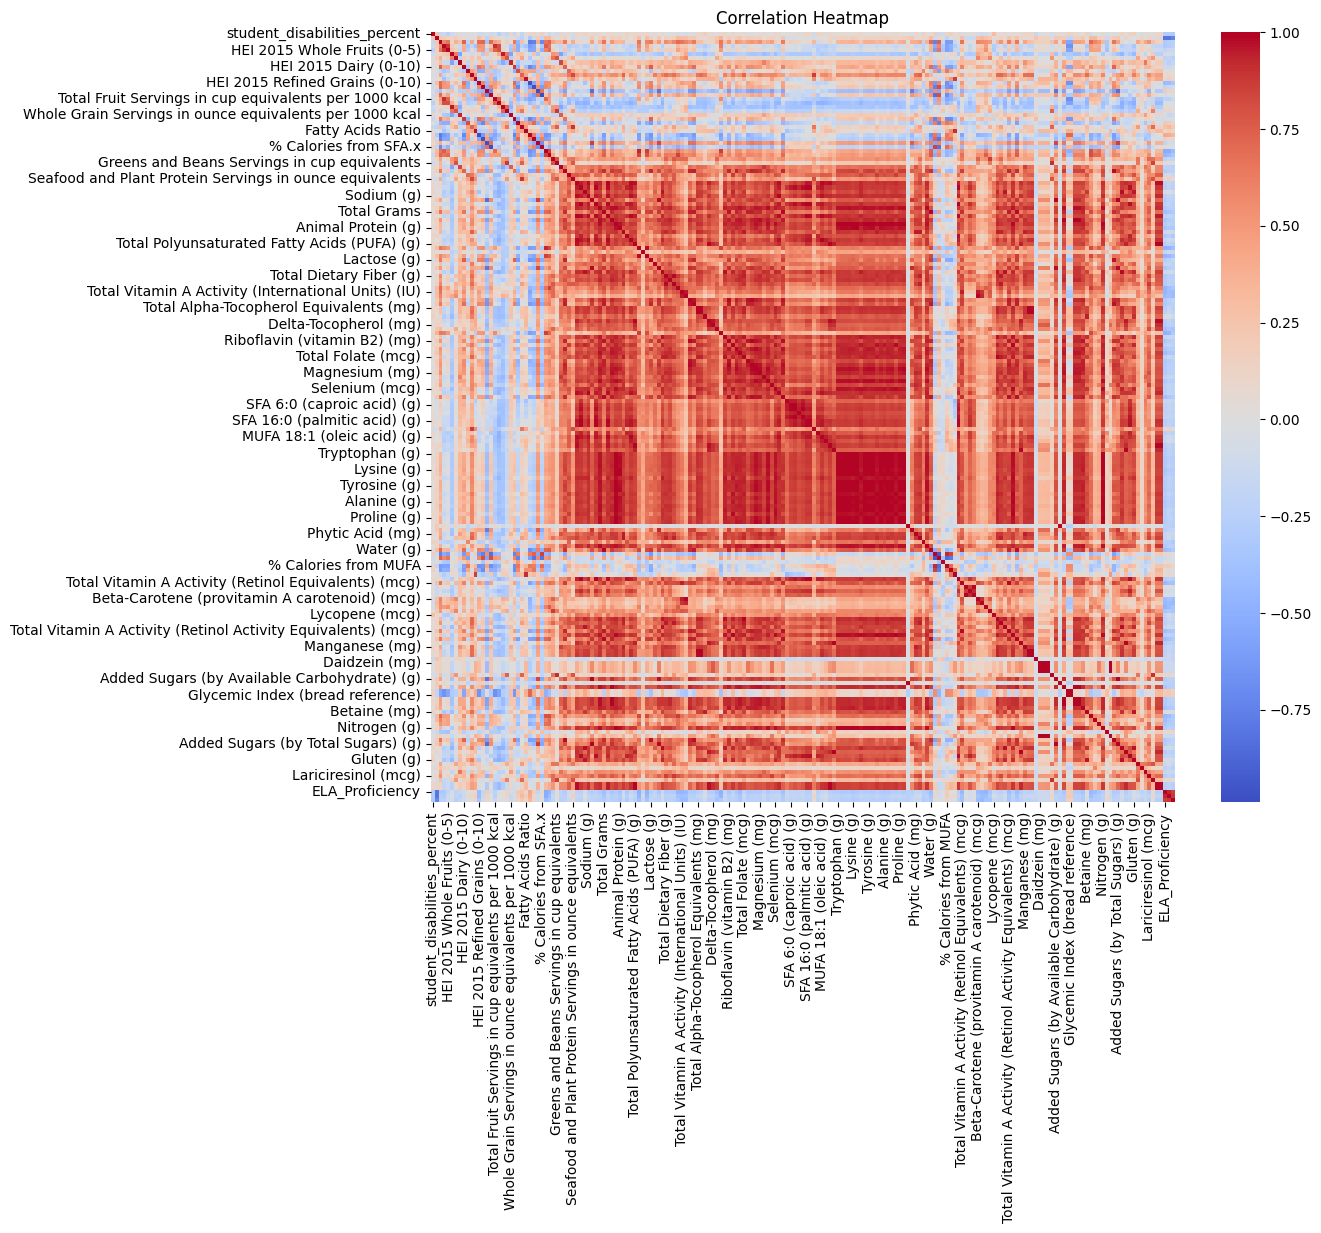

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(cor_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [30]:
targets = ["ELA_Proficiency", "Math_Proficiency", "Science_Proficiency"]

cor_target = cor_matrix[targets]

# Top features for ELA
cor_target["ELA_Proficiency"].abs().sort_values(ascending=False).head(15)

ELA_Proficiency                                         1.000000
Math_Proficiency                                        0.926131
Science_Proficiency                                     0.857235
student_low_income_percent                              0.807847
Total Fruit Servings in cup equivalents                 0.516843
Fructose (g)                                            0.483943
Vitamin C (ascorbic acid) (mg)                          0.478190
Whole Fruit Servings in cup equivalents                 0.462898
Beta-Cryptoxanthin (provitamin A carotenoid) (mcg)      0.461977
Glucose (g)                                             0.460801
Pectins (g)                                             0.456309
Total Vitamin A Activity (International Units) (IU)     0.453394
Inositol (g)                                            0.434082
Total Vitamin A Activity (Retinol Equivalents) (mcg)    0.431757
Alpha-Carotene (provitamin A carotenoid) (mcg)          0.430708
Name: ELA_Proficiency, dt

In [31]:
def remove_high_corr(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    return df.drop(columns=to_drop), to_drop

df_reduced, dropped_cols = remove_high_corr(df_variance_clean, threshold=0.9)

print("Dropped columns:", len(dropped_cols))

Dropped columns: 128


# QUESTION 1: How does academic performance differ in ses context?

In [32]:
import pandas as pd
import statsmodels.api as sm

# Targets
targets = ["ELA_Proficiency", "Math_Proficiency", "Science_Proficiency"]

# SES predictors
ses_vars = ["student_low_income_percent", "student_disabilities_percent"]

for target in targets:
    print(f"\n===== {target} vs SES =====")
    
    X = df_variance_clean[ses_vars]
    y = df_variance_clean[target]
    
    # Add intercept
    X = sm.add_constant(X)
    
    # Fit model
    model = sm.OLS(y, X).fit()
    
    # Extract results
    results = pd.DataFrame({
        "Coefficient": model.params,
        "Std Error": model.bse,
        "t-value": model.tvalues,
        "p-value": model.pvalues
    })
    
    print(results)
    
    print("\nR-squared:", model.rsquared)


===== ELA_Proficiency vs SES =====
                              Coefficient  Std Error    t-value       p-value
const                           82.653164   7.975022  10.364004  3.758251e-14
student_low_income_percent      -0.527620   0.056574  -9.326221  1.316434e-12
student_disabilities_percent    -0.430004   0.445152  -0.965971  3.386169e-01

R-squared: 0.6588586132117457

===== Math_Proficiency vs SES =====
                              Coefficient  Std Error   t-value       p-value
const                           73.866809   8.082246  9.139391  2.528836e-12
student_low_income_percent      -0.532950   0.057334 -9.295445  1.465530e-12
student_disabilities_percent    -0.436133   0.451137 -0.966743  3.382348e-01

R-squared: 0.6574348772138106

===== Science_Proficiency vs SES =====
                              Coefficient  Std Error   t-value       p-value
const                           75.600867   8.363822  9.039034  3.596287e-12
student_low_income_percent      -0.431522   0.05933

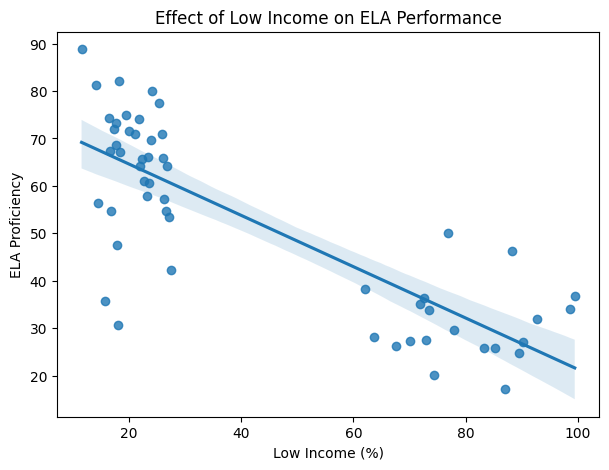

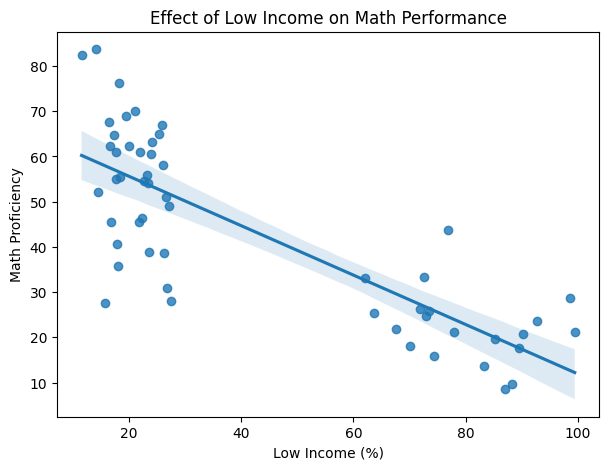

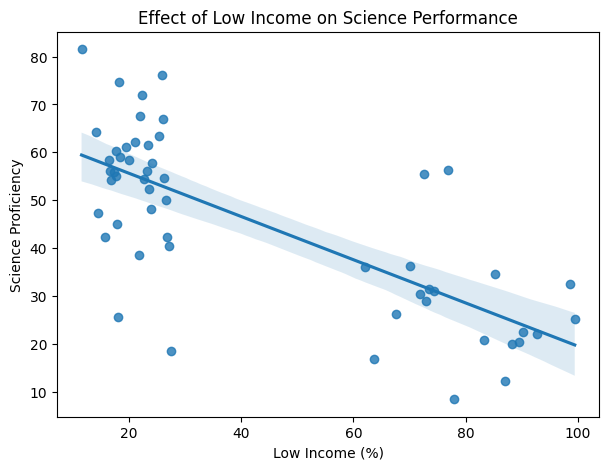

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot for ELA (repeat for Math/Science if needed)
plt.figure(figsize=(7,5))
sns.regplot(
    x="student_low_income_percent",
    y="ELA_Proficiency",
    data=df_variance_clean
)

plt.title("Effect of Low Income on ELA Performance")
plt.xlabel("Low Income (%)")
plt.ylabel("ELA Proficiency")
plt.show()

#Math 
plt.figure(figsize=(7,5))
sns.regplot(
    x="student_low_income_percent",
    y="Math_Proficiency",
    data=df_variance_clean
)

plt.title("Effect of Low Income on Math Performance")
plt.xlabel("Low Income (%)")
plt.ylabel("Math Proficiency")
plt.show()

# Science
plt.figure(figsize=(7,5))
sns.regplot(
    x="student_low_income_percent",
    y="Science_Proficiency",
    data=df_variance_clean
)

plt.title("Effect of Low Income on Science Performance")
plt.xlabel("Low Income (%)")
plt.ylabel("Science Proficiency")
plt.show()

# QUESTION 2: Does nutrition reduce SES inequality?

In [34]:
import pandas as pd
import statsmodels.api as sm

nutrition_var = "HEI 2015 Total Score"

targets = ["ELA_Proficiency", "Math_Proficiency", "Science_Proficiency"]

for target in targets:
    print(f"\n===== {target} | SES × Nutrition Interaction =====")
    
    # Base variables
    df_model = df_variance_clean[[
        target,
        "student_low_income_percent",
        "student_disabilities_percent",
        nutrition_var
    ]].copy()
    
    # Interaction terms
    df_model["low_income_nutrition"] = (
        df_model["student_low_income_percent"] * df_model[nutrition_var]
    )
    
    df_model["disability_nutrition"] = (
        df_model["student_disabilities_percent"] * df_model[nutrition_var]
    )
    
    # Define X and y
    X = df_model.drop(columns=[target])
    y = df_model[target]
    
    # Add intercept
    X = sm.add_constant(X)
    
    # Fit model
    model = sm.OLS(y, X).fit()
    
    # Extract results
    results = pd.DataFrame({
        "Coefficient": model.params,
        "Std Error": model.bse,
        "t-value": model.tvalues,
        "p-value": model.pvalues
    })
    
    print(results)
    
    print("\nR-squared:", model.rsquared)


===== ELA_Proficiency | SES × Nutrition Interaction =====
                              Coefficient  Std Error   t-value   p-value
const                          212.684074  81.948487  2.595339  0.012499
student_low_income_percent      -0.028477   0.375045 -0.075931  0.939790
student_disabilities_percent    -7.361927   4.312157 -1.707249  0.094237
HEI 2015 Total Score            -2.164716   1.369338 -1.580848  0.120481
low_income_nutrition            -0.008373   0.006576 -1.273303  0.209043
disability_nutrition             0.115391   0.072624  1.588879  0.118654

R-squared: 0.7025264914442968

===== Math_Proficiency | SES × Nutrition Interaction =====
                              Coefficient  Std Error   t-value   p-value
const                          220.407494  83.298296  2.646002  0.010980
student_low_income_percent       0.062047   0.381222  0.162757  0.871393
student_disabilities_percent    -8.829247   4.383185 -2.014345  0.049595
HEI 2015 Total Score            -2.450643   1.3

In [35]:
df_plot = df_variance_clean.copy()

# Split into Low SES and High SES (median split)
median_income = df_plot["student_low_income_percent"].median()

df_plot["SES_group"] = df_plot["student_low_income_percent"].apply(
    lambda x: "Low SES" if x > median_income else "High SES"
)

<Figure size 700x500 with 0 Axes>

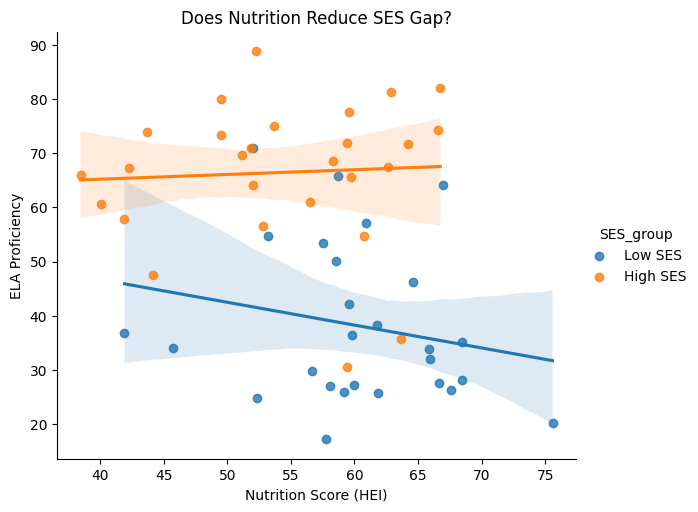

In [36]:
plt.figure(figsize=(7,5))

sns.lmplot(
    x="HEI 2015 Total Score",
    y="ELA_Proficiency",
    hue="SES_group",
    data=df_plot,
    aspect=1.2
)

plt.title("Does Nutrition Reduce SES Gap?")
plt.xlabel("Nutrition Score (HEI)")
plt.ylabel("ELA Proficiency")
plt.show()

The orange line is always above the blue line, High SES schools always perform better, Gap is always there.
Blue line → slightly going down, Orange line → slightly flat.
Even if nutrition improves, the gap between rich and poor schools does not shrink

 Nutrition does not reduce the SES gap — high SES schools continue to outperform low SES schools at all nutrition levels.

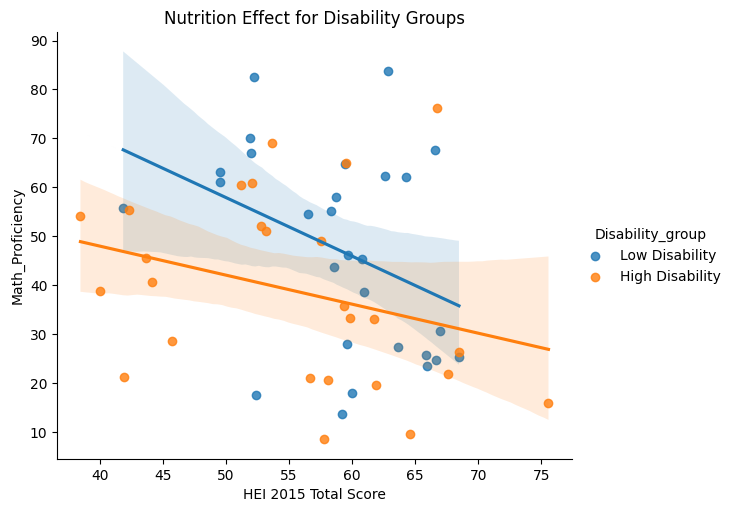

In [37]:
median_disability = df_plot["student_disabilities_percent"].median()

df_plot["Disability_group"] = df_plot["student_disabilities_percent"].apply(
    lambda x: "High Disability" if x > median_disability else "Low Disability"
)

sns.lmplot(
    x="HEI 2015 Total Score",
    y="Math_Proficiency",
    hue="Disability_group",
    data=df_plot,
    aspect=1.2
)

plt.title("Nutrition Effect for Disability Groups")
plt.show()

Blue = Low disability schools, Orange = High disability schools

Nutrition might be helping reduce differences between disability groups slightly

Nutrition shows a slight potential to reduce differences for disability groups, but the effect is weak and not very clear.

# QUESTION3: WHICH NUTRITION VARIABLES ACTUALLY AFFECT THE ACADEMIC PERFORMANCE?

# Model 1: HEI v/s Scores 

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd

In [39]:
def compute_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
    return vif_data

In [40]:
# HEI variables (same as before)
hei_vars = [
   0
]

targets = ["ELA_Proficiency", "Math_Proficiency", "Science_Proficiency"]

for target in targets:
    print(f"\n===== {target} | HEI Components + VIF =====")
    
    X = df_variance_clean[hei_vars]
    y = df_variance_clean[target]
    
    # Add intercept
    X_const = sm.add_constant(X)
    
    # Fit model
    model = sm.OLS(y, X_const).fit()
    
    # Regression results
    results = pd.DataFrame({
        "Coefficient": model.params,
        "Std Error": model.bse,
        "t-value": model.tvalues,
        "p-value": model.pvalues
    })
    
    # Compute VIF (exclude intercept)
    vif = compute_vif(X)
    
    # Merge results with VIF
    results = results.reset_index().rename(columns={"index": "Variable"})
    results = results.merge(vif, on="Variable", how="left")
    
    print(results)
    print("\nR-squared:", model.rsquared)


===== ELA_Proficiency | HEI Components + VIF =====


KeyError: "None of [Index([0], dtype='int64')] are in the [columns]"

# MODEL 2: HEI total score v/s academic scores

In [ ]:
import statsmodels.api as sm
import pandas as pd

targets = ["ELA_Proficiency", "Math_Proficiency", "Science_Proficiency"]

for target in targets:
    print(f"\n===== {target} | HEI Total Score =====")
    
    X = df_variance_clean[["HEI 2015 Total Score"]]
    y = df_variance_clean[target]
    
    # Add intercept
    X = sm.add_constant(X)
    
    # Fit model
    model = sm.OLS(y, X).fit()
    
    # Results table
    results = pd.DataFrame({
        "Coefficient": model.params,
        "Std Error": model.bse,
        "t-value": model.tvalues,
        "p-value": model.pvalues
    })
    
    print(results)
    print("\nR-squared:", model.rsquared)


===== ELA_Proficiency | HEI Total Score =====
                      Coefficient  Std Error   t-value   p-value
const                   94.151824  18.155973  5.185722  0.000004
HEI 2015 Total Score    -0.731062   0.314046 -2.327881  0.023844

R-squared: 0.0943768931818253

===== Math_Proficiency | HEI Total Score =====
                      Coefficient  Std Error   t-value   p-value
const                   79.076238  18.628410  4.244927  0.000090
HEI 2015 Total Score    -0.627063   0.322218 -1.946084  0.057058

R-squared: 0.0678872787893886

===== Science_Proficiency | HEI Total Score =====
                      Coefficient  Std Error   t-value   p-value
const                   76.351011  16.992204  4.493296  0.000039
HEI 2015 Total Score    -0.541653   0.293916 -1.842881  0.071050

R-squared: 0.06130765263417992


# MODEL 3: HEI components (not HEI total) v/s scores

In [ ]:
hei_components = [
    "HEI 2015 Total Fruits (0-5)",
    "HEI 2015 Whole Fruits (0-5)",
    "HEI 2015 Total Vegetables (0-5)",
    "HEI 2015 Greens and Beans (0-5)",
    "HEI 2015 Whole Grains (0-10)",
    "HEI 2015 Dairy (0-10)",
    "HEI 2015 Total Protein Foods (0-5)",
    "HEI 2015 Seafood and Plant Proteins (0-5)"
]

In [ ]:
for target in targets:
    print(f"\n===== {target} | HEI Components (No Total Score) =====")
    
    X = df_variance_clean[hei_components]
    y = df_variance_clean[target]
    
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    
    results = pd.DataFrame({
        "Coefficient": model.params,
        "Std Error": model.bse,
        "t-value": model.tvalues,
        "p-value": model.pvalues
    })
    
    print(results)
    print("\nR-squared:", model.rsquared)


===== ELA_Proficiency | HEI Components (No Total Score) =====
                                           Coefficient  Std Error   t-value  \
const                                        99.903845  26.450980  3.776943   
HEI 2015 Total Fruits (0-5)                  -9.225990   4.210607 -2.191131   
HEI 2015 Whole Fruits (0-5)                   5.141067   4.558039  1.127912   
HEI 2015 Total Vegetables (0-5)               0.309315   4.061953  0.076149   
HEI 2015 Greens and Beans (0-5)              -6.557135   3.808490 -1.721715   
HEI 2015 Whole Grains (0-10)                 -2.821935   1.475862 -1.912058   
HEI 2015 Dairy (0-10)                        -0.006971   1.392869 -0.005005   
HEI 2015 Total Protein Foods (0-5)           -5.417539   4.536320 -1.194259   
HEI 2015 Seafood and Plant Proteins (0-5)     1.795022   2.754372  0.651699   

                                            p-value  
const                                      0.000463  
HEI 2015 Total Fruits (0-5)           

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
    return vif_data

In [ ]:
X = df_variance_clean[hei_components]
vif = compute_vif(X)

print(vif)

                                    Variable        VIF
0                HEI 2015 Total Fruits (0-5)  41.576379
1                HEI 2015 Whole Fruits (0-5)  58.347811
2            HEI 2015 Total Vegetables (0-5)  22.355969
3            HEI 2015 Greens and Beans (0-5)   7.917090
4               HEI 2015 Whole Grains (0-10)   4.110221
5                      HEI 2015 Dairy (0-10)  17.101490
6         HEI 2015 Total Protein Foods (0-5)  15.224492
7  HEI 2015 Seafood and Plant Proteins (0-5)   5.304627


# MODEL 4: SES variables + HEI all components v/s academic scores

In [ ]:
ses_vars = ["student_low_income_percent", "student_disabilities_percent"]

for target in targets:
    print(f"\n===== {target} | HEI + SES =====")
    
    X = df_variance_clean[hei_vars + ses_vars]
    y = df_variance_clean[target]
    
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    
    print(model.summary())


===== ELA_Proficiency | HEI + SES =====
                            OLS Regression Results                            
Dep. Variable:        ELA_Proficiency   R-squared:                       0.739
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     10.79
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           4.71e-09
Time:                        18:07:06   Log-Likelihood:                -201.34
No. Observations:                  54   AIC:                             426.7
Df Residuals:                      42   BIC:                             450.5
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

# MODEL 5: LASSO REGRESSION

In [ ]:
# Outcomes
target_cols = [
    "ELA_Proficiency",
    "Math_Proficiency",
    "Science_Proficiency"
]

# SES
ses_cols = [
    "student_low_income_percent",
    "student_disabilities_percent"
]

# Identify HEI + serving columns
drop_keywords = [
    "HEI",
    "Servings",
    "per 1000 kcal"
]

nutrition_cols = [
    col for col in df_variance_clean.columns
    if col not in target_cols + ses_cols
    and not any(keyword in col for keyword in drop_keywords)
]

df_nutrients = df_variance_clean[nutrition_cols + ses_cols + target_cols]

print("Final shape:", df_nutrients.shape)

Final shape: (54, 159)


In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = df_nutrients[nutrition_cols + ses_cols]
y = df_nutrients["ELA_Proficiency"]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = LassoCV(cv=5).fit(X_scaled, y)

lasso_coef = pd.Series(lasso.coef_, index=X.columns)

important_vars = lasso_coef[lasso_coef != 0].sort_values(key=abs, ascending=False)

print("Selected variables:\n", important_vars.head(15))

/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.069e+00, tolerance: 1.657e+00
  model = cd_fast.enet_coordinate_descent(
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.154e+00, tolerance: 1.657e+00
  model = cd_fast.enet_coordinate_descent(
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

Selected variables:
 student_low_income_percent                                                -12.724562
Beta-Cryptoxanthin (provitamin A carotenoid) (mcg)                         -2.617183
Fructose (g)                                                               -2.091367
Beta-Carotene Equivalents (derived from provitamin A carotenoids) (mcg)    -1.077850
MUFA 16:1 (palmitoleic acid) (g)                                           -1.052001
% Calories from SFA.x                                                      -0.767613
student_disabilities_percent                                               -0.689837
Galactose (g)                                                              -0.525689
Aspartame (mg)                                                             -0.456527
SFA 22:0 (behenic acid) (g)                                                 0.326625
Sorbitol (g)                                                               -0.094869
Tagatose (mg)                               

/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.168e+00, tolerance: 1.802e+00
  model = cd_fast.enet_coordinate_descent(
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.205e+00, tolerance: 1.802e+00
  model = cd_fast.enet_coordinate_descent(
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

In [ ]:
import statsmodels.api as sm

selected_vars = important_vars.index.tolist()

X_final = df_nutrients[selected_vars]
y = df_nutrients["ELA_Proficiency"]

X_final = sm.add_constant(X_final)

model = sm.OLS(y, X_final).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        ELA_Proficiency   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     14.92
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           2.46e-11
Time:                        18:07:07   Log-Likelihood:                -192.20
No. Observations:                  54   AIC:                             410.4
Df Residuals:                      41   BIC:                             436.3
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

# MODEL 6: USING SELECTED NUTRITION COMPONENETS

In [ ]:
selected_nutrients = [
    # Fruits & vegetables
    "Total Fruit Servings in cup equivalents",
    "Total Vegetable Servings in cup equivalents",
    
    # Grains
    "Whole Grain Servings in ounce equivalents",
    
    # Dairy
    "Dairy Servings in cup equivalents",
    
    # Macros
    "Total Fat (g)",
    "Total Protein (g)",
    "Energy (kcal).x",
    
    # Key micros
    "Sodium (mg)",
    "Vitamin C (ascorbic acid) (mg)",
    "Total Vitamin A Activity (Retinol Equivalents) (mcg)",
    "Calcium (mg)",
    "Iron (mg)",
    "Zinc (mg)"
]

In [ ]:
target_cols = [
    "ELA_Proficiency",
    "Math_Proficiency",
    "Science_Proficiency"
]

ses_cols = [
    "student_low_income_percent",
    "student_disabilities_percent"
]

df_model = df_variance_clean[selected_nutrients + ses_cols + target_cols]

print(df_model.shape)

(54, 18)


In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_model[selected_nutrients + ses_cols])

X_scaled = pd.DataFrame(
    X_scaled,
    columns=selected_nutrients + ses_cols
)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_vif = sm.add_constant(X_scaled)

vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif)

                                             Variable         VIF
0                                               const    1.000000
1             Total Fruit Servings in cup equivalents    7.674703
2         Total Vegetable Servings in cup equivalents    4.385547
3           Whole Grain Servings in ounce equivalents    9.588089
4                   Dairy Servings in cup equivalents   15.775887
5                                       Total Fat (g)   41.758354
6                                   Total Protein (g)   60.005218
7                                     Energy (kcal).x  103.808144
8                                         Sodium (mg)   28.680811
9                      Vitamin C (ascorbic acid) (mg)    6.399335
10  Total Vitamin A Activity (Retinol Equivalents)...   11.718113
11                                       Calcium (mg)   33.811933
12                                          Iron (mg)   30.063034
13                                          Zinc (mg)   86.461865
14        

In [ ]:
# Example manual drop
X_scaled = X_scaled.drop(columns=["Energy (kcal).x"])

In [ ]:
import statsmodels.api as sm

for target in target_cols:
    print(f"\n===== {target} =====")
    
    y = df_model[target]
    X = sm.add_constant(X_scaled)
    
    model = sm.OLS(y, X).fit()
    print(model.summary())


===== ELA_Proficiency =====
                            OLS Regression Results                            
Dep. Variable:        ELA_Proficiency   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     11.27
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.13e-09
Time:                        18:07:07   Log-Likelihood:                -193.86
No. Observations:                  54   AIC:                             417.7
Df Residuals:                      39   BIC:                             447.5
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

### Model Diagnostics

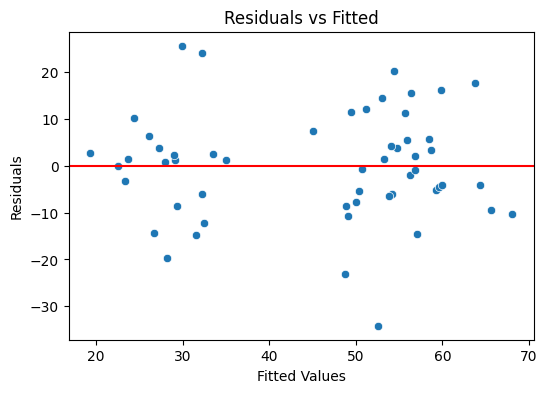

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Assuming model = your fitted OLS model
residuals = model.resid
fitted = model.fittedvalues

# 1. Residuals vs Fitted (Linearity + Homoscedasticity)
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

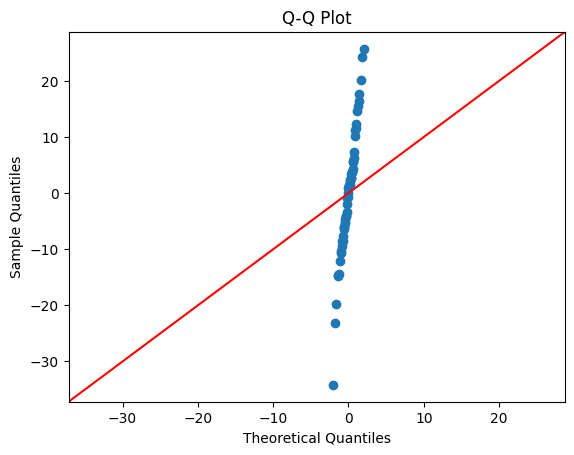

In [42]:
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot")
plt.show()

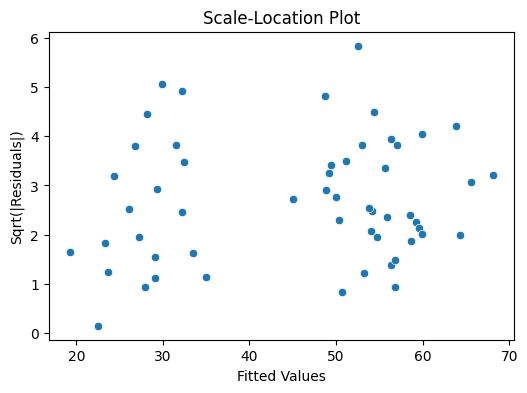

In [43]:
import numpy as np

plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=np.sqrt(np.abs(residuals)))
plt.xlabel("Fitted Values")
plt.ylabel("Sqrt(|Residuals|)")
plt.title("Scale-Location Plot")
plt.show()

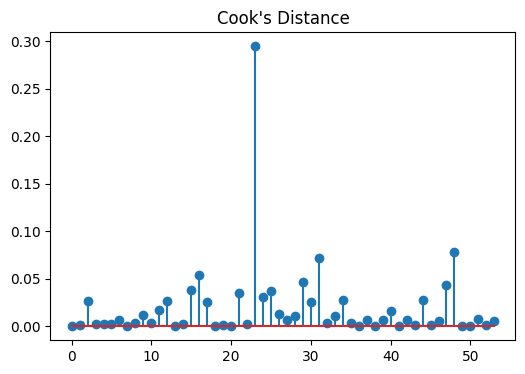

In [44]:
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(6,4))
plt.stem(cooks_d)
plt.title("Cook's Distance")
plt.show()

In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = model.model.exog
vif = [variance_inflation_factor(X, i) for i in range(X.shape[1])]

# Question 4: How do academic performance differ across districts? (north, south, east, west)

In [ ]:
# original dataset (before cleaning)
df_original = pd.read_csv("Dataset/academic_meals_elementary_district.csv")

# merge district back using index OR key column
df_variance_clean["District"] = df_original["District"]

/var/folders/7w/vrg67xp53xq_j1lvk8w5th380000gn/T/ipykernel_85296/2873011622.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_variance_clean["District"] = df_original["District"]


In [ ]:
region_map = {
    # NORTH
    "AURORA EAST USD 131": "North",
    "DEKALB CUSD 428": "North",
    "FREEPORT SD 145": "North",
    "HARLEM UD 122": "North",
    "HUNTLEY COMMUNITY SCHOOL DISTRICT 158": "North",
    "NAPERVILLE CUSD 203": "North",
    "NORTH CHICAGO SD 187": "North",
    "ROCKFORD SD 205": "North",
    "ROUND LAKE CUSD 116": "North",
    "ST CHARLES CUSD 303": "North",
    "SYCAMORE CUSD 427": "North",
    "WAUKEGAN CUSD 60": "North",
    "YORKVILLE CUSD 115": "North",
    "HINCKLEY BIG ROCK CUSD 429": "North",
    "BEECHER CUSD 200U": "North",
    "CRETE MONEE CUSD 201U": "North",

    # CENTRAL
    "BALL CHATHAM CUSD 5": "Central",
    "BRIMFIELD CUSD 309": "Central",
    "DUNLAP CUSD 323": "Central",
    "EUREKA CUD 140": "Central",
    "GALESBURG CUSD 205": "Central",
    "HEYWORTH CUSD 4": "Central",
    "ILLINI CENTRAL CUSD 189": "Central",
    "LEXINGTON CUSD 7": "Central",
    "PEORIA SD 150": "Central",
    "ROCHESTER CUSD 3A": "Central",
    "TREMONT CUSD 702": "Central",
    "TRI VALLEY CUSD 3": "Central",
    "URBANA SD 116": "Central",
    "WILLIAMSVILLE CUSD 15": "Central",

    # SOUTH
    "CARRIER MILLS-STONEFORT CUSD 2": "South",
    "CRAB ORCHARD CUSD 3": "South",
    "DONGOLA USD 66": "South",
    "MURPHYSBORO CUSD 186": "South",

    # EAST
    "DANVILLE CCSD 118": "East",
    "EDWARDSVILLE CUSD 7": "East",
    "MASCOUTAH CUD 19": "East",
    "TRIAD CUSD 2": "East",
    "VALMEYER CUSD 3": "East",
    "WATERLOO CUSD 5": "East",

    # WEST
    "DEPUE USD 103": "West",
    "DIETERICH CUSD 30": "West",
    "KANKAKEE SD 111": "West",
    "KEWANEE CUSD 229": "West",
    "LOSTANT CUSD 425": "West",
    "MEREDOSIA-CHAMBERSBURG CUSD 11": "West",
    "ORION CUSD 223": "West",
    "PEOTONE CUSD 207U": "West",
    "RIVERDALE CUSD 100": "West",
    "WARSAW CUSD 316": "West",
    "WEST WASHINGTON CO CUD 10": "West"
}

In [ ]:
df_variance_clean["Region"] = df_variance_clean["District"].map(region_map)

df_variance_clean = df_variance_clean.dropna(subset=["Region"])

/var/folders/7w/vrg67xp53xq_j1lvk8w5th380000gn/T/ipykernel_85296/945606166.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_variance_clean["Region"] = df_variance_clean["District"].map(region_map)


In [ ]:
from scipy.stats import f_oneway

def run_anova(target):
    groups = [
        df_variance_clean[df_variance_clean["Region"] == r][target]
        for r in df_variance_clean["Region"].unique()
    ]
    
    f_stat, p_val = f_oneway(*groups)
    
    print(f"\n===== {target} ANOVA =====")
    print("F-stat:", f_stat)
    print("p-value:", p_val)

# Run for all
run_anova("ELA_Proficiency")
run_anova("Math_Proficiency")
run_anova("Science_Proficiency")


===== ELA_Proficiency ANOVA =====
F-stat: 0.8966718885304691
p-value: 0.473703384336289

===== Math_Proficiency ANOVA =====
F-stat: 1.6956160965702225
p-value: 0.1672496908513722

===== Science_Proficiency ANOVA =====
F-stat: 1.288401040679177
p-value: 0.288434825964029


In [ ]:
df_variance_clean.groupby("Region")[[
    "ELA_Proficiency",
    "Math_Proficiency",
    "Science_Proficiency"
]].mean()

,ELA_Proficiency,Math_Proficiency,Science_Proficiency
Region,,,
Central,57.001438,48.584853,48.407357
East,56.934722,49.025000,48.964635
North,46.706133,37.463456,38.673480
South,41.150000,24.475000,32.411495
West,50.311210,41.651831,48.905801


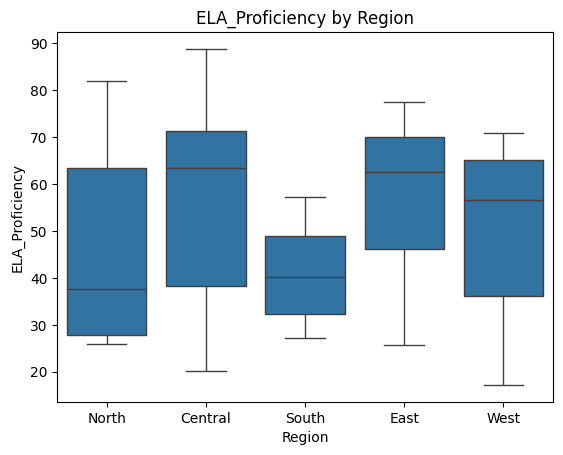

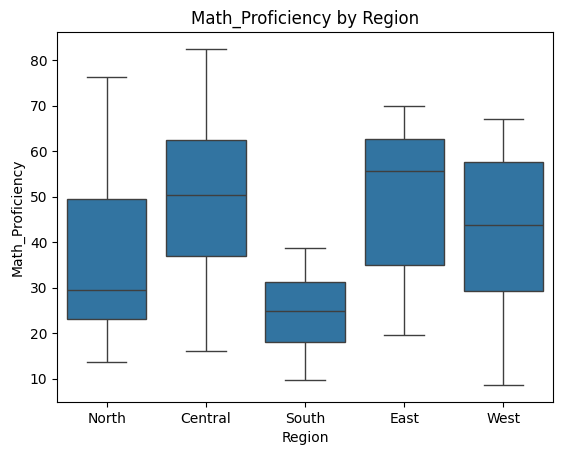

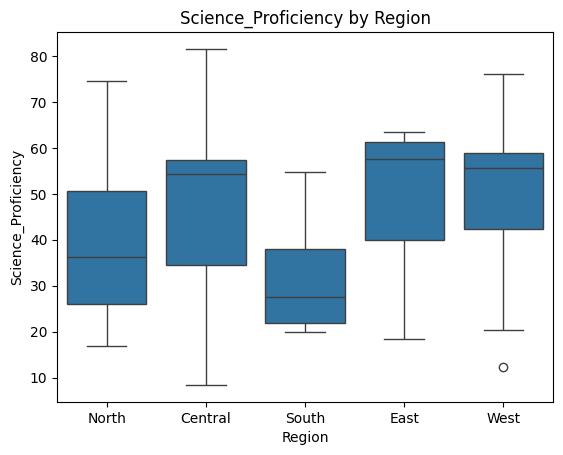

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for target in ["ELA_Proficiency", "Math_Proficiency", "Science_Proficiency"]:
    plt.figure()
    sns.boxplot(x="Region", y=target, data=df_variance_clean)
    plt.title(f"{target} by Region")
    plt.show()

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df_variance_clean["ELA_Proficiency"],
    groups=df_variance_clean["Region"],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1 group2 meandiff p-adj   lower    upper  reject
------------------------------------------------------
Central   East  -0.0667    1.0 -27.4697 27.3362  False
Central  North -10.2953 0.6169 -30.8475 10.2569  False
Central  South -15.8514 0.6224 -47.6908 15.9879  False
Central   West  -6.6902 0.9169 -29.3175  15.937  False
   East  North -10.2286 0.8157 -37.1128 16.6556  False
   East  South -15.7847 0.7305 -52.0354  20.466  False
   East   West  -6.6235 0.9639 -35.1255 21.8784  False
  North  South  -5.5561 0.9867 -36.9502 25.8379  False
  North   West   3.6051 0.9901 -18.3911 25.6013  False
  South   West   9.1612 0.9313 -23.6288 41.9512  False
------------------------------------------------------
